In [ ]:
setwd("ICH_Stroke/")
getwd()
args = commandArgs(trailingOnly=TRUE)
print(args)
options(future.globals.maxSize = 100000000 * 1024^2)

# set random seed for reproducibility
set.seed(12345)
print(args)

# ========================= Libraries ===================================

# Data manipulation and meta-analysis
library(dplyr)
library(tidyr)
library(broom)
library(tidyverse)
library(metafor)

# Single-cell analysis
library(Seurat)
library(SingleCellExperiment)
library(scater)
library(scuttle)
library(muscat)

# Co-expression network analysis
library(WGCNA)
library(hdWGCNA)
library(igraph)

# Batch effect correction
library(harmony)

# Visualization and plotting
library(ggplot2)
library(cowplot)
library(patchwork)
library(ggtree)
library(aplot)
library(circlize)
library(ComplexHeatmap)
library(RColorBrewer)
library(scCustomize)
library(dittoSeq)

# Functional enrichment analysis
library(clusterProfiler)
library(org.Hs.eg.db)

# Additional utilities
library(doParallel)
library(SCopeLoomR)
library(dreamlet)

# Custom operator
'%notin%' <- Negate('%in%')



workdir <- "7.WGCNA/"
source('utils.R')
dir.create(workdir)
registerDoParallel(cores=threads)
colors <- brewer.pal(n = 9, name = 'Set3')
colors[2] <- colors[8]
colors[8] <- "azure3"
colors_rb <- rev(brewer.pal(n = 6, name = 'RdGy'))


In [39]:
Calculate_Fisher_Enrichement<-function(List1,List2,Background){
    # A is the number of items in both lists (e.g., up-regulated genes and a specific gene set).
    A <-length(intersect(List1,List2))

    # B is the number of items in the first list but not in the second list.
    B <- length(List1[!List1%in%List2])

    # C is the number of items in the second list but not in the first list.
    C <- length(List2[!List2%in%List1])

    # D is the number of items not in either list.
    D <- length(Background[!Background%in%c(List1,List2) ])
    
    # Create a 2x2 contingency table
    # Replace the values with your actual data
    observed_data <- matrix(c(
      A, B, C, D
    ), nrow = 2)

    # Perform the Fisher's exact test
    fisher_result <- fisher.test(observed_data)

    # Print the results
#     print(fisher_result)

    # Extract the p-value from the Fisher's test result
    p_value <- fisher_result$p.value
    if(p_value<0.05){
        odd_ratio <- fisher_result$estimate
    }else{
        odd_ratio <- 0
    }
    odd_ratio
}


# Function to calculate enrichment score
calculate_enrichment_score <- function(gene_list, gene_set) {
  overlap <- length(intersect(gene_list, gene_set))
  return(overlap / length(gene_set))
}


Calculate_Fisher_Enrichement2<-function(List1,List2,Background){
    # A is the number of items in both lists (e.g., up-regulated genes and a specific gene set).
    A <-length(intersect(List1,List2))

    # B is the number of items in the first list but not in the second list.
    B <- length(List1[!List1%in%List2])

    # C is the number of items in the second list but not in the first list.
    C <- length(List2[!List2%in%List1])

    # D is the number of items not in either list.
    D <- length(Background[!Background%in%c(List1,List2) ])
    
    # Create a 2x2 contingency table
    # Replace the values with your actual data
    observed_data <- matrix(c(
      A, B, C, D
    ), nrow = 2)

    # Perform the Fisher's exact test
    fisher_result <- fisher.test(observed_data)

    # Print the results
    print(fisher_result)

    # Extract the p-value from the Fisher's test result
    p_value <- fisher_result$p.value
    odd_ratio <- as.numeric(fisher_result$estimate)
    list(p_value=p_value,odd_ratio=odd_ratio)
}

universalGsea<-function(GeneList,GeneSet,Background_genes){
    require(reshape2)
    require(GeneOverlap)
    require(fdrtool)
    gom.obj=newGOM(GeneList, GeneSet, length(Background_genes))
    if(length(names(GeneList))==1){
        z=cbind(
          names(GeneList),
          sub(paste0("\\.",names(GeneList)),"",rownames(melt(getMatrix(gom.obj, name="pval")))),
          melt(getMatrix(gom.obj, name="pval")),
          melt(getMatrix(gom.obj, name="odds.ratio"))[,1],
          melt(getMatrix(gom.obj, name="intersection"))[,1],
          melt(getMatrix(gom.obj, name="union"))[,1],
          melt(getMatrix(gom.obj, name="Jaccard"))[,1]
        )
      }else{
        z=cbind(
          melt(getMatrix(gom.obj, name="pval")),
          melt(getMatrix(gom.obj, name="odds.ratio"))[,3],
          melt(getMatrix(gom.obj, name="intersection"))[,3],
          melt(getMatrix(gom.obj, name="union"))[,3],
          melt(getMatrix(gom.obj, name="Jaccard"))[,3]
        )
      }
    colnames(z) = c("Set", "Reference", "pval", "odds.ratio", "intersection", "union", "Jaccard")
    z$Bonf_AdjP = p.adjust(z$pval, method = "bonferroni")
    z$BH_AdjP = p.adjust(z$pval, method = "BH")
    z$Z = qnorm(1-(z$pval)/2)
    z$LogP = -log10(z$pval)
    z$FDR_AdjP=fdrtool(z$pval, statistic="pvalue", plot=F,cutoff.method="fndr", verbose=F)$qval
    z=z[order(z$pval),]
    z$Cross <- ifelse(z$FDR_AdjP < 0.05, "Significant", "NS")
    z$Cross_FDR <- ifelse(z$pval < 0.05, "Significant", "NS")
    lengths_of_genesets <- sapply(GeneList,length)
    z$NGeneListGenes <-  lengths_of_genesets[z$Set]
    z$GeneRatio <- z$intersection / z$NGeneListGenes # Assuming a total of 100 genes in your dataset
    rownames(z) <- NULL
    return(z)
}


In [40]:
Project_Colors <- c(
  MG = '#279e68',      # dark green
  PVM = '#ff7f0e',     # dark orange
  Homeo = '#279e68',   # dark green
  Adapt = '#1f77b4',   # blue
  ADAM = '#d62728',    # red ***
  Prolif = '#dbdb8d',  # light yellow ***
  exAM = '#ff9896',    # light pink
  Homeo_FRMD4A = '#279e68',     # dark green
  Homeo_PICALM = '#98df8a',      # light green
  Adapt_TMEM163 = '#1f77b4',     # blue
  Adapt_IFI44L = '#17becf',      # cyan
  Adapt_HSPA1A = '#9edae5',      # light blue
  Adapt_HIF1A = '#aec7e8',       # light blue
  Adapt_AIF1 = '#c5b0d5',        # light purple
  Adapt_HIST = '#867CB9',        # violet ***
  Adapt_CCL3 = '#aa40fc',        # purple
  ADAM_GPNMB = '#d62728',        # red ***
  Prolif_MKI67 = '#dbdb8d',      # light yellow ***
  exAM_ERN1 = '#ff9896',         # light pink
  PVM_CD163 = '#ff7f0e'          # dark orange
)


In [41]:
WGCNA_dir = 'ICH_Stroke/result/Cortex/7.WGCNA/'
SCENIC_dir = 'ICH_Stroke/result/Cortex/8.SCENIC/'
input_rds <-  paste0(WGCNA_dir,'2024_03_28_Myeloid_Metacells_Subclass_ADAM.rds.ztsd')
input_loom <-  paste0(SCENIC_dir,'Myeloid/2024_04_01_Myeloid_Metacells_ExtendedGenes.loom')

Metacells <- readCRDS(input_rds)
Metacells$TwoClusters <-  as.vector(Metacells$Clusters)
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_1","MTC_2","MTC_3")] <- "MTC_123"
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_4","MTC_5","MTC_6")]<- "MTC_456"


In [42]:
library(SCENIC)
loom_path_output <- '2024_04_01_Metacells_Pred_Data_processed_ext.loom'

# Load the Loom file
loom <- open_loom(loom_path_output)

# Extract regulons from the Loom file
regulons_incidMat <- get_regulons(loom, column.attr.name = "Regulons")

# Convert regulons to gene lists
regulons <- regulonsToGeneLists(regulons_incidMat)

# Calculate AUC (Area Under the Curve) for regulons
regulonAUC <- get_regulons_AUC(loom, column.attr.name = 'RegulonsAUC')

# Compute AUC matrix
AUCmat <- AUCell::getAUC(regulonAUC)

# Clean up row names by removing parentheses
rownames(AUCmat) <- gsub("[(+)]", "", rownames(AUCmat))

In [43]:
# Create an assay object for AUC scores
Metacells[['AUC']] <- CreateAssayObject(data = AUCmat)


In [44]:
options(repr.plot.width=12, repr.plot.height=6)
p1 <- DimPlot(Metacells,group.by = 'Subclass',cols=Project_Colors)
p2 <- DimPlot(Metacells,group.by = 'Clusters')
p3 <- DimPlot(Metacells,group.by = 'TwoClusters')


In [45]:
subset_two_cl <- subset(Metacells,TwoClusters%in% c('MTC_123','MTC_456'))

In [46]:
# DefaultAssay(subset_two_cl) <- 'AUC'
# Idents(subset_two_cl) <- "TwoClusters"
# DEG_TFs <- FindAllMarkers(subset_two_cl,
#                        only.pos = T,
#                        logfc.threshold =0,min.pct=0.1,assay='AUC')
# DEG_TFs$TF_symbol <- DEG_TFs$gene
# DEG_TFs$log2FC <- ifelse(DEG_TFs$cluster == 'MTC_456', DEG_TFs$avg_log2FC, -1 * DEG_TFs$avg_log2FC)
# write.csv(DEG_TFs,'2025_SCENIC_DEG_TFs.csv')
DEG_TFs <- read.csv('2025_SCENIC_DEG_TFs.csv')

In [47]:
head(DEG_TFs,2)

,X,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,TF_symbol,log2FC
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
1,SPI1,0,0.1176293,1,1,0,MTC_456,SPI1,SPI1,0.1176293
2,PPARG,0,0.1011717,1,1,0,MTC_456,PPARG,PPARG,0.1011717


In [48]:
# DefaultAssay(subset_two_cl) <- 'RNA'
# Idents(subset_two_cl) <- "TwoClusters"
# DEGs_genes <- FindAllMarkers(subset_two_cl,
#                        only.pos = T,
#                        logfc.threshold =0,min.pct=0.1,assay='RNA')
# DEGs_genes$log2FC <- ifelse(DEGs_genes$cluster == 'MTC_456', DEGs_genes$avg_log2FC, -1 * DEGs_genes$avg_log2FC)
# write.csv(DEGs_genes,'2025_SCENIC_DEGs_genes.csv')
DEGs_genes <- read.csv('2025_SCENIC_DEGs_genes.csv')

In [49]:
head(DEGs_genes,2)

,X,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,log2FC
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,SPP1,0,3.610863,1.000,1.000,0,MTC_456,SPP1,3.610863
2,TIMP1,0,3.235379,0.991,0.861,0,MTC_456,TIMP1,3.235379


In [50]:
dim(DEG_TFs)
dim(DEGs_genes)

[1] 88 10

[1] 11220     9

In [51]:
Background <- rownames(subset_two_cl)

In [52]:
# Combine upregulated and downregulated genes to obtain overall differentially expressed genes
up_genes <- DEGs_genes$gene[DEGs_genes$cluster=='MTC_456']
down_genes <-DEGs_genes$gene[DEGs_genes$cluster=='MTC_123']
overall_genes <- unique(c(up_genes, down_genes))

# Create a list for gene enrichment analysis
DEGs_list <- list(
  "Upregulated" = up_genes,
  "Downregulated" = down_genes,
  "Disregulated" = overall_genes
)


In [97]:
perform_fisher_tests <- function(DEGs_list, TF_list, background_genes, fdr_threshold = 0.05) {
    require(dplyr)
    
    # Initialize an empty dataframe to store results
    results <- data.frame(
    DEG_List = character(),
    TF = character(),
    GeneRatio = numeric(),
    OddsRatio = numeric(),
    PValue = numeric(),
    FDR = numeric(),
    Significance = character(),
    stringsAsFactors = FALSE
    )
    
    # Loop through each DEG list
    for (deg_name in names(DEGs_list)) {
        deg_genes <- DEGs_list[[deg_name]]
        
        # Loop through each TF and its regulated genes
        for (tf_name in names(TF_list)) {
            tf_genes <- TF_list[[tf_name]]
            tf_symbol <- gsub("[(+)]", "", tf_name)

            # Perform Fisher's exact test
            fisher_result <- Calculate_Fisher_Enrichement2(deg_genes, tf_genes, background_genes)
            
            # Calculate GeneRatio
            gene_ratio <- length(intersect(deg_genes, tf_genes)) / length(deg_genes)
            
            # Append results to the dataframe
            results <- rbind(results, data.frame(
            Reference= deg_name,
            DEG_List = deg_name,
            TF_name = tf_name,
            TF_symbol =tf_symbol,
            GeneRatio = gene_ratio,
            OddsRatio = fisher_result$odd_ratio,
            PValue = fisher_result$p_value,
            FDR = NA, # Will be filled later
            Significance = NA, # Will be filled later
            stringsAsFactors = FALSE
            ))
        }
    }
    
    # Adjust p-values using Benjamini-Hochberg method
    results$FDR <- p.adjust(results$PValue, method = "BH")
    results$Q_value <- p.adjust(results$PValue, method = "bonferroni")
    
    # Determine significance based on FDR threshold
    results$Significance <- ifelse(results$FDR < fdr_threshold, "Significant", "NS")
    
    # Sort results by FDR
    results <- results[order(results$FDR), ]
    
    return(results)
}

In [98]:
Calculate_Fisher_Enrichement2 <- function(List1, List2, Background) {
  # A is the number of items in both lists
  A <- length(intersect(List1, List2))

  # B is the number of items in the first list but not in the second list
  B <- length(List1[!List1 %in% List2])

  # C is the number of items in the second list but not in the first list
  C <- length(List2[!List2 %in% List1])

  # D is the number of items not in either list
  D <- length(Background[!Background %in% c(List1, List2)])

  # Create a 2x2 contingency table
  observed_data <- matrix(c(A, B, C, D), nrow = 2)

  # Perform Fisher's exact test
  fisher_result <- fisher.test(observed_data)

  # Extract p-value and odds ratio
  p_value <- fisher_result$p.value
  odd_ratio <- as.numeric(fisher_result$estimate)

  # Return results as a list
  list(p_value = p_value, odd_ratio = odd_ratio)
}

In [99]:
# Remove parentheses from the names of regulons
regulons_plain <- gsub("[(+)]", "", names(regulons))
# Assign regulons to gene_sets
TF_list <- regulons

# FISHER EXACT TEST

In [100]:
SPI1_TARGETS <- TF_list$`SPI1(+)`


In [ ]:
universalGsea(list(Downregulated=DEGs_list$Downregulated),list(SPI1=SPI1_TARGETS),Background)

In [ ]:
universalGsea(list(Upregulated=DEGs_list$Upregulated),list(SPI1=SPI1_TARGETS),Background)

In [103]:
Calculate_Fisher_Enrichement2(DEGs_list$Downregulated,SPI1_TARGETS,Background)

$p_value
[1] 1.298119e-26

$odd_ratio
[1] 0.0552897

In [104]:
Calculate_Fisher_Enrichement2(DEGs_list$Upregulated,SPI1_TARGETS,Background)

$p_value
[1] 7.043462e-77

$odd_ratio
[1] 50.9858

In [105]:
Fisher_results <- perform_fisher_tests(DEGs_list,TF_list, Background)


In [106]:
head(Fisher_results)

,Reference,DEG_List,TF_name,TF_symbol,GeneRatio,OddsRatio,PValue,FDR,Significance,Q_value
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
209,Downregulated,Downregulated,MAF(+),MAF,0.10082769,19.66677,4.720390e-212,1.982564e-209,Significant,1.982564e-209
238,Downregulated,Downregulated,PURA(+),PURA,0.07562077,23.53032,5.202875e-165,1.092604e-162,Significant,2.185208e-162
70,Upregulated,Upregulated,MAFB(+),MAFB,0.08749230,24.74529,1.609219e-153,2.252907e-151,Significant,6.758720e-151
222,Downregulated,Downregulated,NFIA(+),NFIA,0.07135691,21.44936,9.518752e-153,9.994689e-151,Significant,3.997876e-150
148,Downregulated,Downregulated,BHLHE41(+),BHLHE41,0.06809631,10.63453,4.043838e-118,3.396824e-116,Significant,1.698412e-115
205,Downregulated,Downregulated,KLF2(+),KLF2,0.06596438,10.27806,4.021815e-113,2.815270e-111,Significant,1.689162e-110


In [107]:
Fisher_results$DF_TF <- Fisher_results$TF_symbol %in% DEG_TFs$gene
Fisher_Merged_TF_DF <- merge(Fisher_results,DEG_TFs,by = 'TF_symbol')

In [108]:
head(Fisher_Merged_TF_DF)

,TF_symbol,Reference,DEG_List,TF_name,GeneRatio,OddsRatio,PValue,FDR,Significance,Q_value,DF_TF,X,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,log2FC
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,ARID3A,Upregulated,Upregulated,ARID3A(+),0.002156500,0.9915546,1.000000e+00,1.000000e+00,NS,1.000000e+00,TRUE,ARID3A,0.00000e+00,0.02379276,1,0.971,0.000000e+00,MTC_123,ARID3A,-0.02379276
2,ARID3A,Disregulated,Disregulated,ARID3A(+),0.003030303,4.7682042,5.776564e-04,1.488440e-03,Significant,2.426157e-01,TRUE,ARID3A,0.00000e+00,0.02379276,1,0.971,0.000000e+00,MTC_123,ARID3A,-0.02379276
3,ARID3A,Downregulated,Downregulated,ARID3A(+),0.003386005,2.9386720,1.745053e-03,4.117542e-03,Significant,7.329224e-01,TRUE,ARID3A,0.00000e+00,0.02379276,1,0.971,0.000000e+00,MTC_123,ARID3A,-0.02379276
4,ATF3,Disregulated,Disregulated,ATF3(+),0.019073084,4.1909137,3.293875e-17,1.921427e-16,Significant,1.383427e-14,TRUE,ATF3,3.62383e-225,0.02444634,1,1.000,5.073362e-223,MTC_123,ATF3,-0.02444634
5,ATF3,Downregulated,Downregulated,ATF3(+),0.011537497,0.7246936,1.628703e-02,3.081330e-02,Significant,1.000000e+00,TRUE,ATF3,3.62383e-225,0.02444634,1,1.000,5.073362e-223,MTC_123,ATF3,-0.02444634
6,ATF3,Upregulated,Upregulated,ATF3(+),0.037584720,4.5608558,2.677985e-29,2.556258e-28,Significant,1.124754e-26,TRUE,ATF3,3.62383e-225,0.02444634,1,1.000,5.073362e-223,MTC_123,ATF3,-0.02444634


In [109]:
max_Odd_plus_ONE <- max(Fisher_Merged_TF_DF$OddsRatio[is.finite(Fisher_Merged_TF_DF$OddsRatio)])+1
Fisher_Merged_TF_DF$OddsRatio[is.infinite(Fisher_Merged_TF_DF$OddsRatio)]<- max_Odd_plus_ONE

In [110]:
Fisher_Result_Sign <- Fisher_Merged_TF_DF%>%filter(DF_TF & Significance=='Significant')

In [114]:
head(Fisher_Result_Sign)

,TF_symbol,Reference,DEG_List,TF_name,GeneRatio,OddsRatio,PValue,FDR,Significance,Q_value,DF_TF,X,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,log2FC
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,ARID3A,Disregulated,Disregulated,ARID3A(+),0.003030303,4.7682042,5.776564e-04,1.488440e-03,Significant,2.426157e-01,TRUE,ARID3A,0.00000e+00,0.02379276,1.000,0.971,0.000000e+00,MTC_123,ARID3A,-0.02379276
2,ARID3A,Downregulated,Downregulated,ARID3A(+),0.003386005,2.9386720,1.745053e-03,4.117542e-03,Significant,7.329224e-01,TRUE,ARID3A,0.00000e+00,0.02379276,1.000,0.971,0.000000e+00,MTC_123,ARID3A,-0.02379276
3,ATF3,Disregulated,Disregulated,ATF3(+),0.019073084,4.1909137,3.293875e-17,1.921427e-16,Significant,1.383427e-14,TRUE,ATF3,3.62383e-225,0.02444634,1.000,1.000,5.073362e-223,MTC_123,ATF3,-0.02444634
4,ATF3,Downregulated,Downregulated,ATF3(+),0.011537497,0.7246936,1.628703e-02,3.081330e-02,Significant,1.000000e+00,TRUE,ATF3,3.62383e-225,0.02444634,1.000,1.000,5.073362e-223,MTC_123,ATF3,-0.02444634
5,ATF3,Upregulated,Upregulated,ATF3(+),0.037584720,4.5608558,2.677985e-29,2.556258e-28,Significant,1.124754e-26,TRUE,ATF3,3.62383e-225,0.02444634,1.000,1.000,5.073362e-223,MTC_123,ATF3,-0.02444634
6,ATF4,Upregulated,Upregulated,ATF4(+),0.005237215,2.2686799,9.390955e-03,1.957214e-02,Significant,1.000000e+00,TRUE,ATF4,0.00000e+00,0.05550814,0.999,0.997,0.000000e+00,MTC_123,ATF4,-0.05550814


In [115]:
Fisher_Disreg <- Fisher_Result_Sign%>%filter(Reference=='Disregulated') %>% arrange(log2FC)
Fisher_Disreg$Set <- factor(Fisher_Disreg$TF_name,levels = unique(Fisher_Disreg$TF_name))

In [117]:
Fisher_UpDown <-  Fisher_Merged_TF_DF %>% 
                    filter(
                        DF_TF &
                        TF_symbol%in%Fisher_Result_Sign$TF_symbol & 
                        Reference!='Disregulated') %>% arrange(log2FC)
Fisher_UpDown$Set <- factor(Fisher_UpDown$TF_name,levels = unique(Fisher_UpDown$TF_name))
Fisher_UpDown$Reference <- factor(Fisher_UpDown$Reference,levels = c('Upregulated','Downregulated'))

In [118]:
Fisher_UpDown %>% filter(TF_symbol=='SPI1')

TF_symbol,Reference,DEG_List,TF_name,GeneRatio,OddsRatio,PValue,FDR,Significance,Q_value,⋯,X,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,log2FC,Set
<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<fct>
SPI1,Downregulated,Downregulated,SPI1(+),0.0007524454,0.0552897,1.298119e-26,1.112674e-25,Significant,5.452101e-24,⋯,SPI1,0,0.1176293,1,1,0,MTC_456,SPI1,0.1176293,SPI1(+)
SPI1,Upregulated,Upregulated,SPI1(+),0.0378927911,50.9858028,7.043462e-77,2.275580e-75,Significant,2.958254e-74,⋯,SPI1,0,0.1176293,1,1,0,MTC_456,SPI1,0.1176293,SPI1(+)


In [119]:
# Generate a bar plot using ggplot
p1 <- ggplot(
      data = Fisher_UpDown,  # Filter data
      aes(x = Set, 
          y = OddsRatio, 
          fill = Reference)  # Define aesthetics
    ) +
geom_bar(stat = "identity", color = "black") +  # Add bar plot
theme_bw() +  # Set theme
RotatedAxis() 
# +theme(axis.title.x = element_blank(),axis.text.x = element_blank(), axis.ticks.x = element_blank())

In [185]:
options(repr.plot.width=7, repr.plot.height=1.5)
p2 <- ggplot(Fisher_Disreg,aes(
        x=Set,
        y=log2FC,
        size=OddsRatio,
        color=log2FC))+
    geom_point()+
    theme_bw()+
    RotatedAxis()+
    scale_color_gradientn(
        colors = c("blue", "lightgrey", "red"), # Gradient colors
        values = scales::rescale(c(min(Fisher_Disreg$log2FC), 0, max(Fisher_Disreg$log2FC)), # Rescale for midpoint
        midpoint = 0 # Midpoint at 0
      ))+
    scale_size_continuous(range = c(0.1, 2)) + # Adjust dot size range (smaller min/max values)
    ylim(-0.2,0.2)+
    theme(
        text = element_text(family = "Helvetica", size = 6), # Set font to Helvetica with size 6
        legend.position = "right", # Move legends to the right
        legend.box = "horizontal", # Arrange legends side by side
        axis.text.x = element_text(angle = 90, hjust = 1) # Rotate x-axis labels vertically
    ) +
    guides(
        color = guide_colorbar(title.position = "top"),
        size = guide_legend(title.position = "top")
    ) 

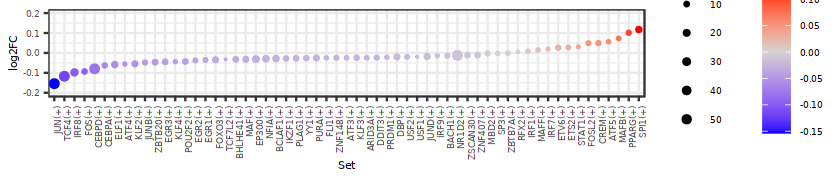

In [186]:
p2

In [ ]:
# Convert mm to inches
width_mm <- 170
height_mm <- 32
width_in <- width_mm * 0.03937
height_in <- height_mm * 0.03937

# Save the plot
ggsave("2025_03_04_Figure2_F_ggplot.pdf", p2, width = width_in, height = height_in, units = "in", dpi = 300)


In [187]:
pdf('/sc/arion/projects/CommonMind/kyriad02/ICH_Stroke/Figures/2025_03_04_Figure2_F.pdf',width = 13,height=2)
set.seed(88888)
options(repr.plot.width=13, repr.plot.height=2)
p2
dev.off()

png 
  2